# Residency-4: Project-1 | Unsupervised Learning | Jayant Ojha

## Problem statement

### Dataset

The dataset was used in the 1983 American Statistical Association Exposition. The data concerns city-cycle fuel consumption in miles per gallon, to be predicted in terms of 2 multivalued discrete and 4 continuous variables. 

Dataset: cars-dataset.csv


**Attributes of the dataset:**

Attribute Information:

Car Name – Name of the car

Cyl – No of cylinders in the car – Multivalued discrete

Disp – Displacement – continuous

Hp – Horsepower – continuous

Wt – Weight – continuous

Acc – Acceleration – continuous

Yr – Model of the car – Multivalued discrete

Mpg - Miles per gallon - continuous

## Question 1

Launch a new python notebook and read the data set. EDA & Pre-processing (Make sure to remove all non-numeric entries from numeric columns) – 5 points

In [529]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity='all'

In [530]:
import warnings 
warnings.filterwarnings('ignore')

In [531]:
import pandas as pd
import numpy as np

In [532]:
#It is good to start with all the features, & stepwise see, if there is any strong corelation across the feature-set. 
df = pd.read_csv("./cars-dataset.csv")
df.reset_index(inplace=True, drop=True)
col_name_full = list(df.columns)
orig_cars_mpg_df = df.loc[:,col_name_full]

In [533]:
orig_cars_mpg_df.sample(n=8, random_state=2)

,car name,cyl,disp,hp,wt,acc,yr,mpg
94,chrysler new yorker brougham,8,440.0,215,4735,11.0,73,13.0
32,ford pinto,4,98.0,?,2046,19.0,71,25.0
279,honda accord lx,4,98.0,68,2135,16.6,78,29.5
178,peugeot 504,4,120.0,88,2957,17.0,75,23.0
354,renault 18i,4,100.0,?,2320,15.8,81,34.5
25,ford f250,8,360.0,215,4615,14.0,70,10.0
67,mercury marquis,8,429.0,208,4633,11.0,72,11.0
188,dodge coronet brougham,8,318.0,150,4190,13.0,76,16.0


In [534]:
orig_cars_mpg_df.shape

(398, 8)

In [535]:
orig_cars_mpg_df.shape

(398, 8)

In [536]:
orig_cars_mpg_df.sample(n=8, random_state=2)

,car name,cyl,disp,hp,wt,acc,yr,mpg
94,chrysler new yorker brougham,8,440.0,215,4735,11.0,73,13.0
32,ford pinto,4,98.0,?,2046,19.0,71,25.0
279,honda accord lx,4,98.0,68,2135,16.6,78,29.5
178,peugeot 504,4,120.0,88,2957,17.0,75,23.0
354,renault 18i,4,100.0,?,2320,15.8,81,34.5
25,ford f250,8,360.0,215,4615,14.0,70,10.0
67,mercury marquis,8,429.0,208,4633,11.0,72,11.0
188,dodge coronet brougham,8,318.0,150,4190,13.0,76,16.0


In [537]:
#Below we use *.info() & *.isnull().any() to find out any null value present
orig_cars_mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [538]:
orig_cars_mpg_df.isnull().any()

car name    False
cyl         False
disp        False
hp          False
wt          False
acc         False
yr          False
mpg         False
dtype: bool

*Above indicates that we do not have any null values in any of the column, but the hp dtype is object, which doesn't seem acceptable, also by drawing a "random sample" using the *.sample, we find a couple of '?' data under hp, we can further look
into the unique values within this distribution*

In [539]:
orig_cars_mpg_df['hp'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [540]:
#Intermediate dataframe, to preserve the 'car name' as column,
#this preservation can potentially help to have the link back
#from clustered PCA-space to original feature space.
#This was required, after a realization after reaching to the 
#PCA + clustering step later.
cars_mpg_df_int = orig_cars_mpg_df[orig_cars_mpg_df['hp'] != '?']

In [541]:
cars_mpg_df_int['hp'] = cars_mpg_df_int['hp'].astype('float')

In [542]:
cars_mpg_df_int.shape

(392, 8)

In [543]:
cars_mpg_df_int.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 392 entries, 0 to 397
Data columns (total 8 columns):
car name    392 non-null object
cyl         392 non-null int64
disp        392 non-null float64
hp          392 non-null float64
wt          392 non-null int64
acc         392 non-null float64
yr          392 non-null int64
mpg         392 non-null float64
dtypes: float64(4), int64(3), object(1)
memory usage: 27.6+ KB


In [544]:
cars_mpg_df_int.reset_index(inplace=True, drop=True)

In [545]:
cars_mpg_df_int.sample(n=8, random_state=2)

,car name,cyl,disp,hp,wt,acc,yr,mpg
55,plymouth cricket,4,91.0,70.0,1955,20.5,71,26.0
70,mazda rx2 coupe,3,70.0,97.0,2330,13.5,72,19.0
313,amc concord,4,151.0,90.0,3003,20.1,80,24.3
179,honda civic cvcc,4,91.0,53.0,1795,17.5,75,33.0
307,vw rabbit,4,98.0,76.0,2144,14.7,80,41.5
324,vw dasher (diesel),4,90.0,48.0,2335,23.7,80,43.4
380,buick century limited,6,181.0,110.0,2945,16.4,82,25.0
108,chevrolet vega,4,140.0,72.0,2401,19.5,73,21.0


In [546]:
car_names_df = cars_mpg_df_int[['car name']]

In [547]:
#the "car name" should be dropped rather than being a feature.
cars_mpg_df = cars_mpg_df_int.drop('car name', axis=1) 
#DROP THIS CELL LATER

In [548]:
#Now, going ahead will turn the 'car name' into index
#cars_mpg_df = cars_mpg_df_int.set_index('car name') 

In [549]:
cars_mpg_df.sample(n=8, random_state=2)

,cyl,disp,hp,wt,acc,yr,mpg
55,4,91.0,70.0,1955,20.5,71,26.0
70,3,70.0,97.0,2330,13.5,72,19.0
313,4,151.0,90.0,3003,20.1,80,24.3
179,4,91.0,53.0,1795,17.5,75,33.0
307,4,98.0,76.0,2144,14.7,80,41.5
324,4,90.0,48.0,2335,23.7,80,43.4
380,6,181.0,110.0,2945,16.4,82,25.0
108,4,140.0,72.0,2401,19.5,73,21.0


In [550]:
cars_mpg_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cyl,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
disp,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
hp,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
wt,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
acc,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
yr,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0
mpg,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6


## Question 2

Use pair plot or scatter matrix to visualize how the different variables are related (Hint: The amount of Gaussian curves in the plot should give a visual identification of different clusters existing in the dataset) – 5 points

In [551]:
from matplotlib import pyplot
import seaborn as sns
%matplotlib inline

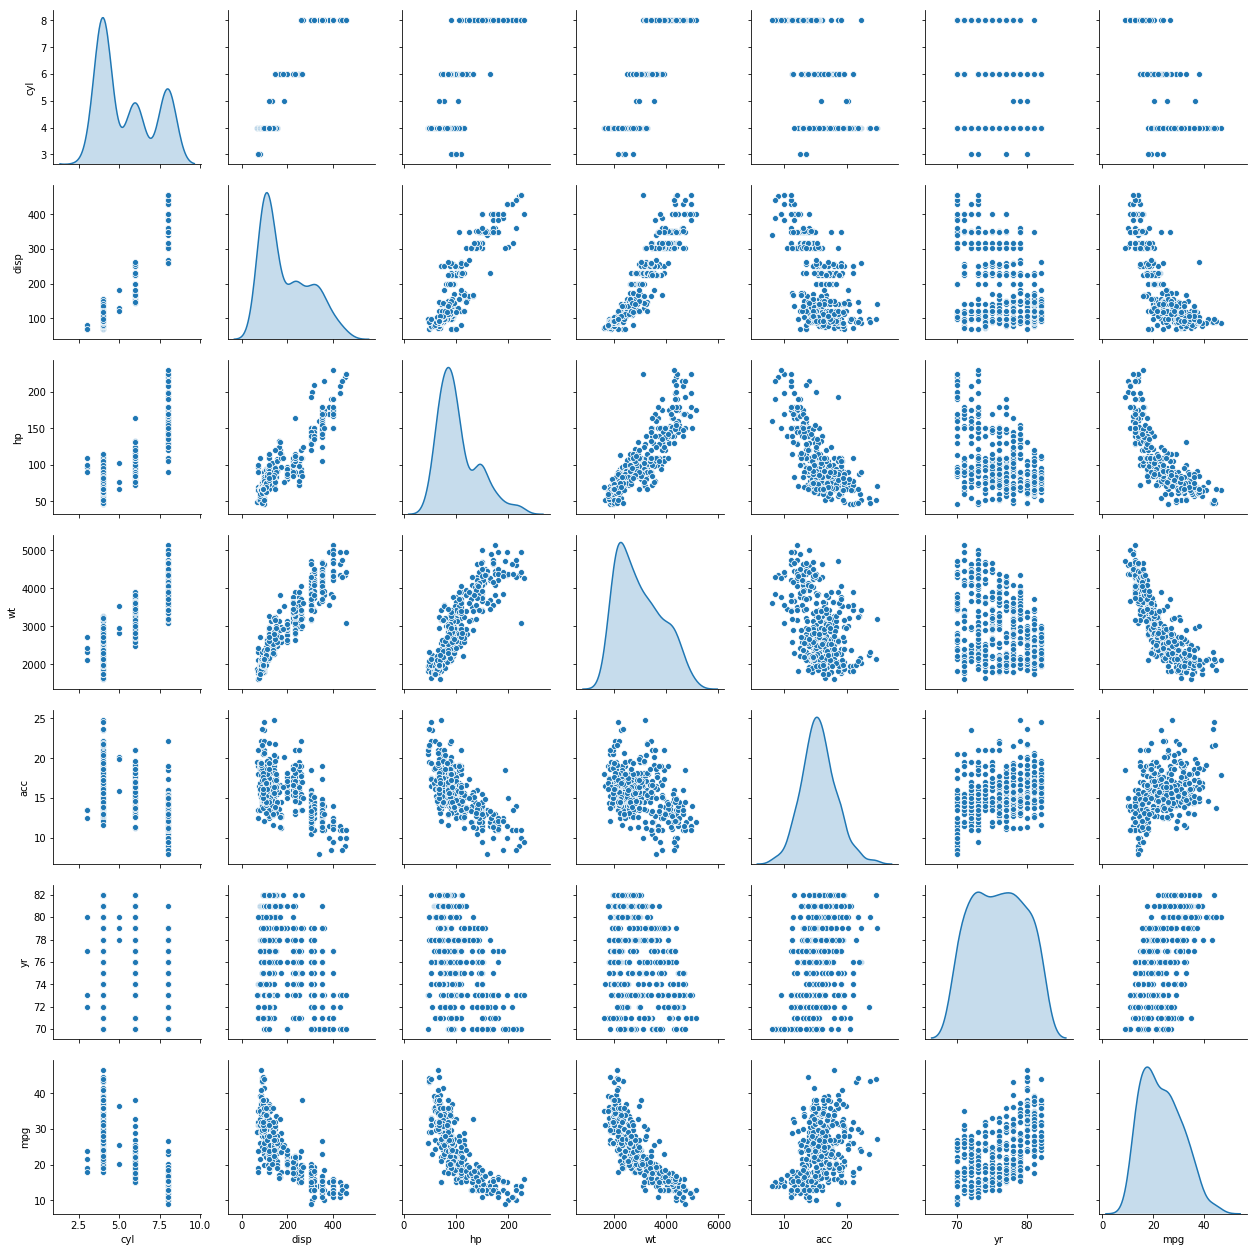

In [552]:
#We need to have a look into  pairplot first for individual feature distributions
#followed by an indivudal histograms later.
#Different diagonal distribution diagram give an approximate idea of presence of number of clusters
#For example we find a presence of minimum 3 "distributiuons/clusters" within the diagonal kde plots.
#Below, for the off-diagonal elements, we find multi-collinearity as well between multiple features.
#This will be further invetigated using the correlation heatmap later, but before that we like to
#look at the individual column distributions separately, as well.
sns.pairplot(cars_mpg_df,diag_kind='kde')

In [553]:
#For ploting the "individual" detailed spread of the histogram, the follwoing function
#is being written...here, default "cut-points" value is 40, & all the "quant" features (which actually are, all of them)
#are selected by using the "describe" dataframe.Then we loop thru individual feature, and the feature-min to feature-max
#is divided into the cut-points (default 40) & plotted in turn.
#Many of the features show outliers (even on a z-score, seen separtely as in a follwing cell, the values go above z= +3.0)
def show_quant_feature_hist_plot(df, cut_pts=40, fig_height=15, fig_len=20):
    #defaul
    descr_trans_df = df.describe()
    for feature in list(descr_trans_df.T.index):
        bins = np.linspace(descr_trans_df[feature]['min'], descr_trans_df[feature]['max'], cut_pts)
        pyplot.subplots(figsize=(fig_len,fig_height))
        #pyplot.hist(df[feature], bins, alpha=0.5, normed=True, label=str(feature)) 
        pyplot.hist(df[feature], bins, alpha=0.5, label=str(feature))
        pyplot.legend(loc='upper right')
        pyplot.show()

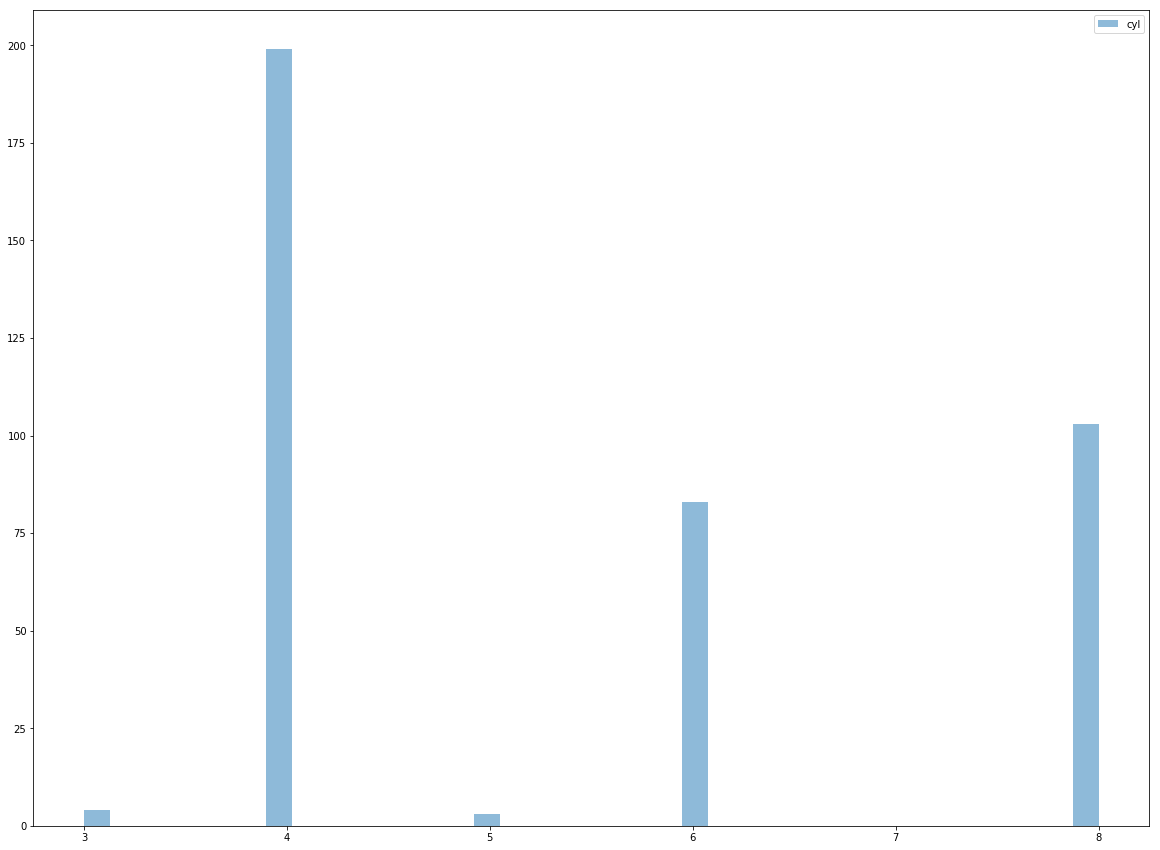

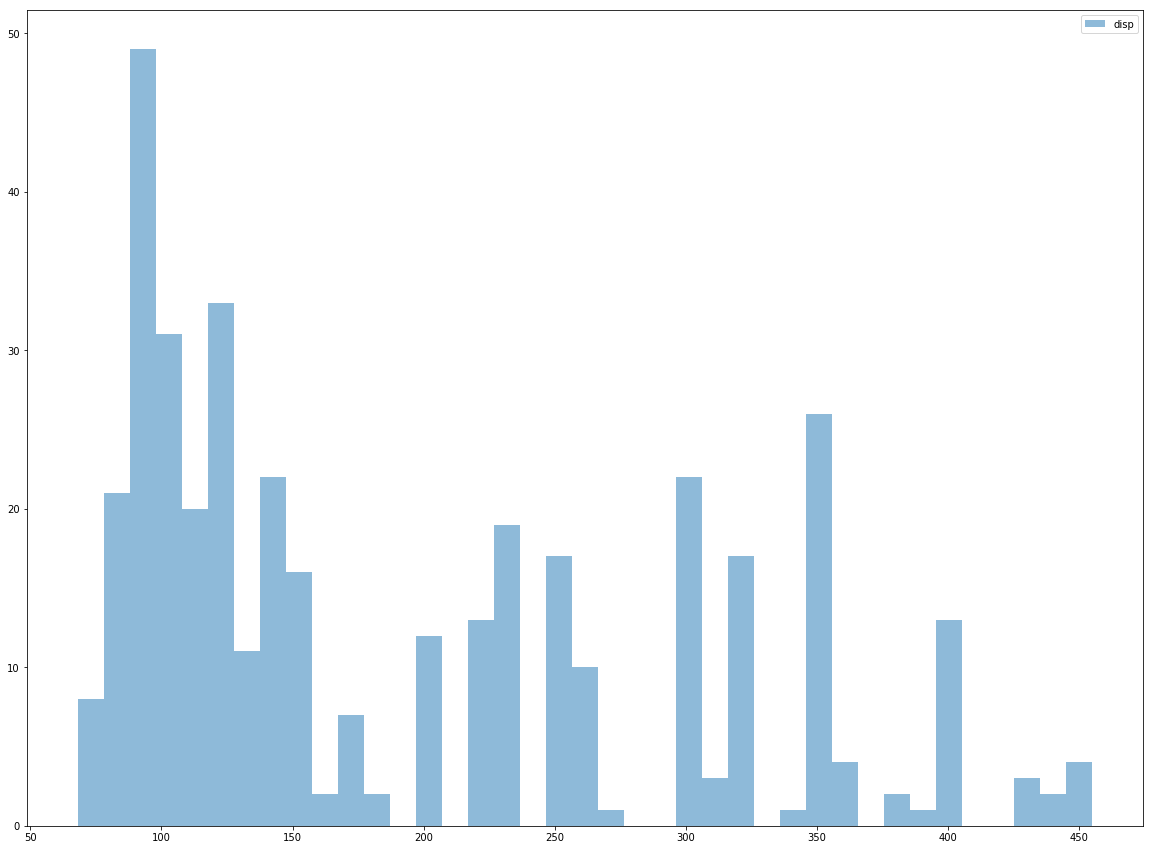

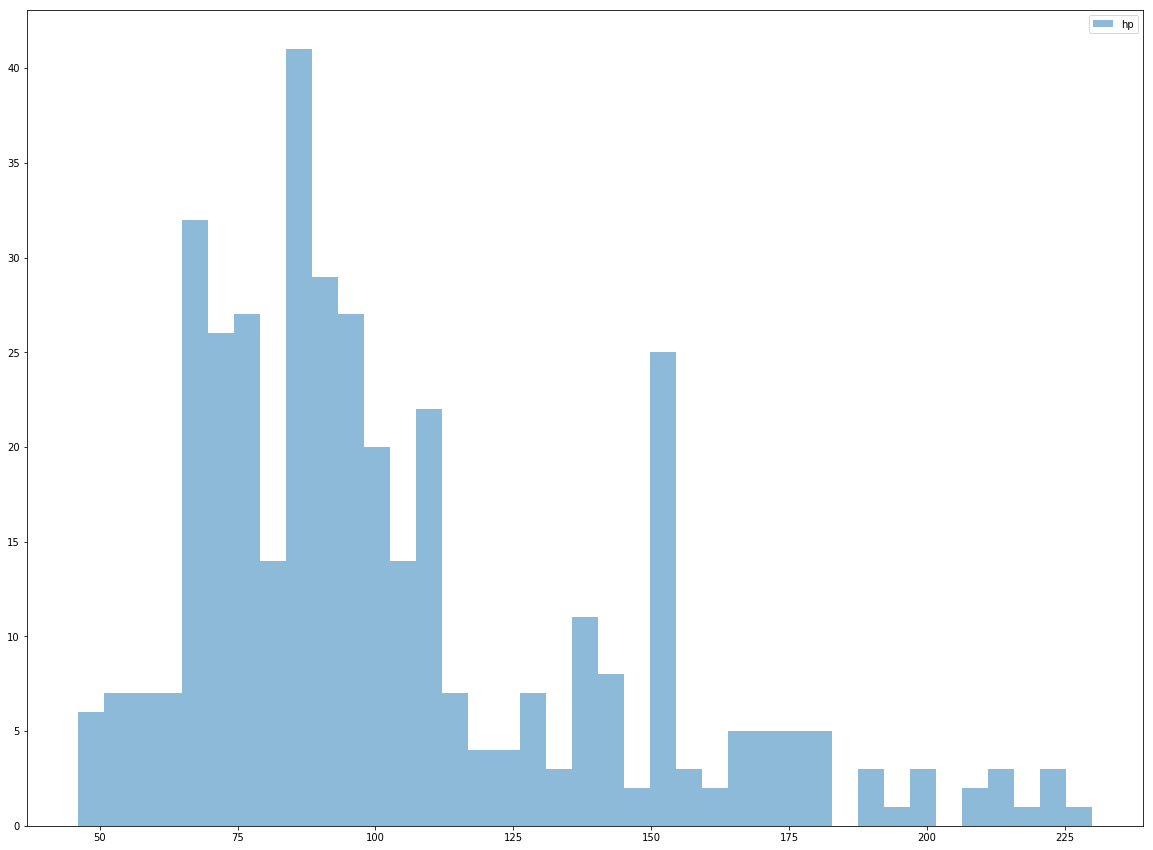

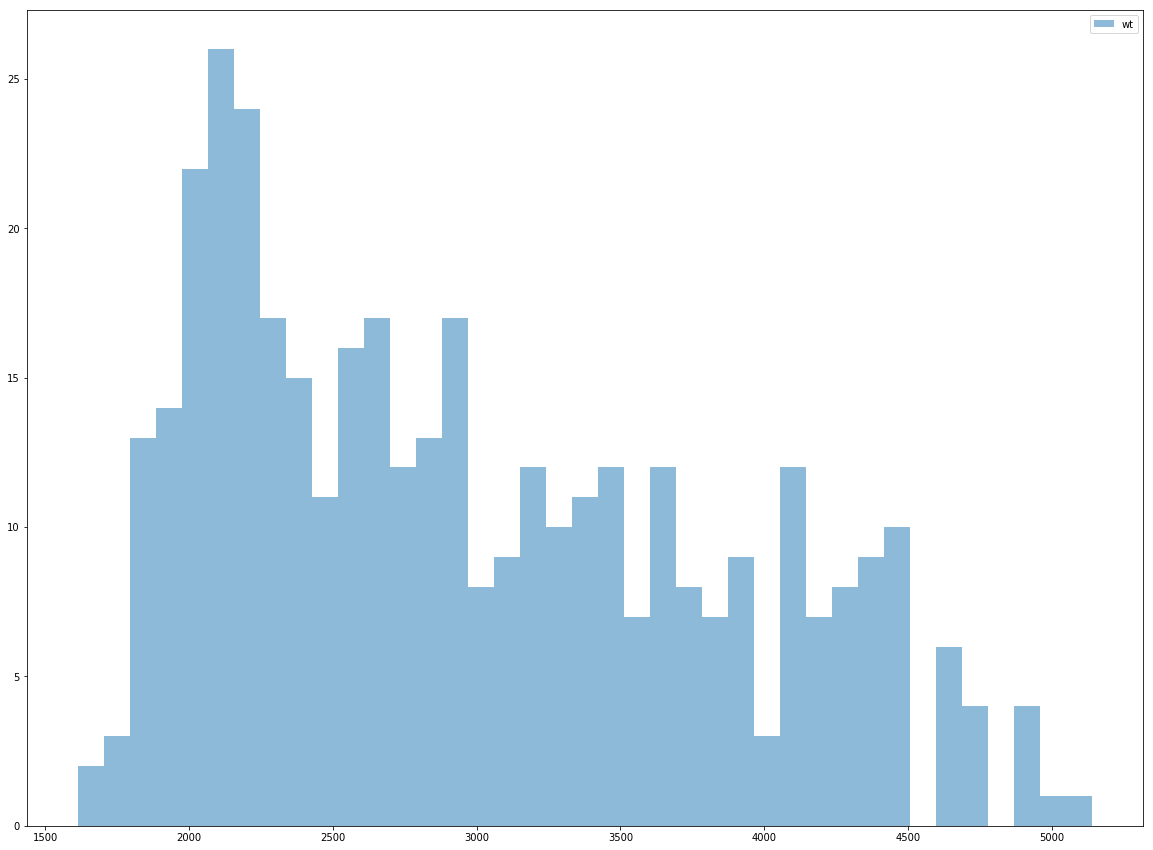

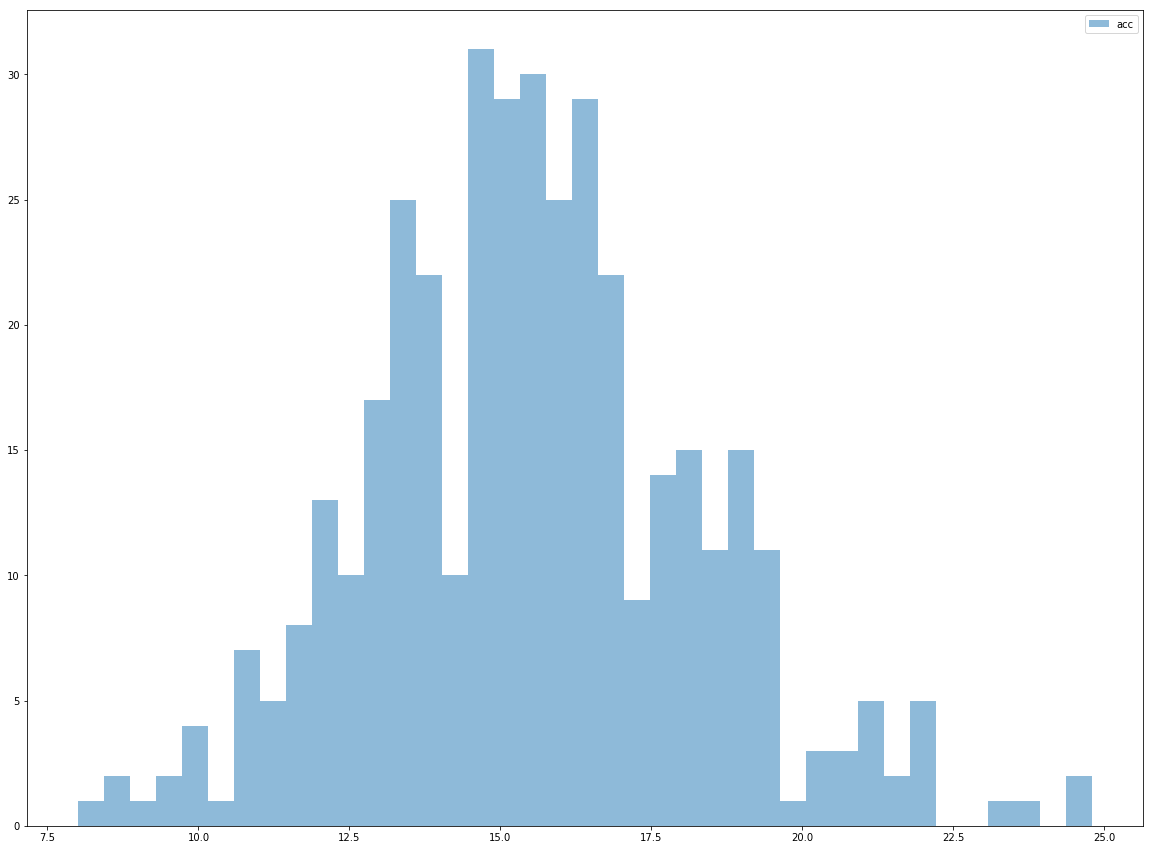

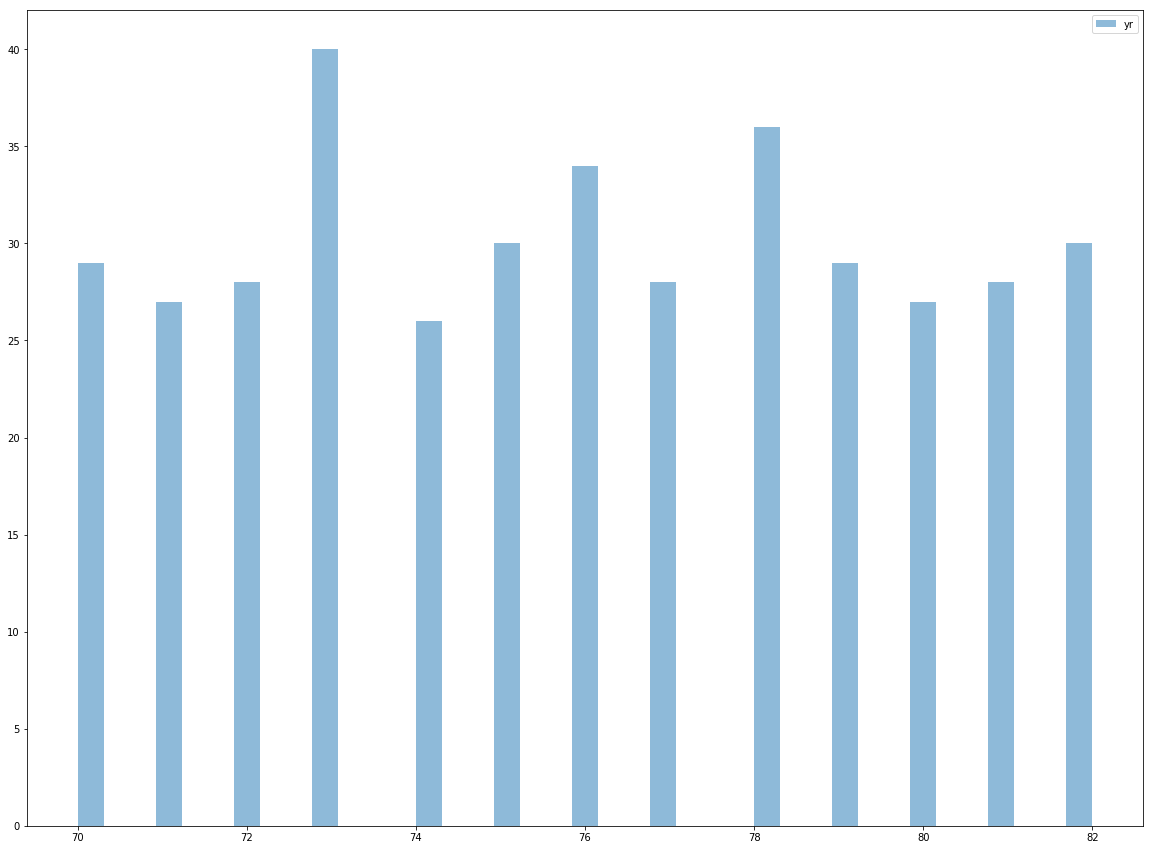

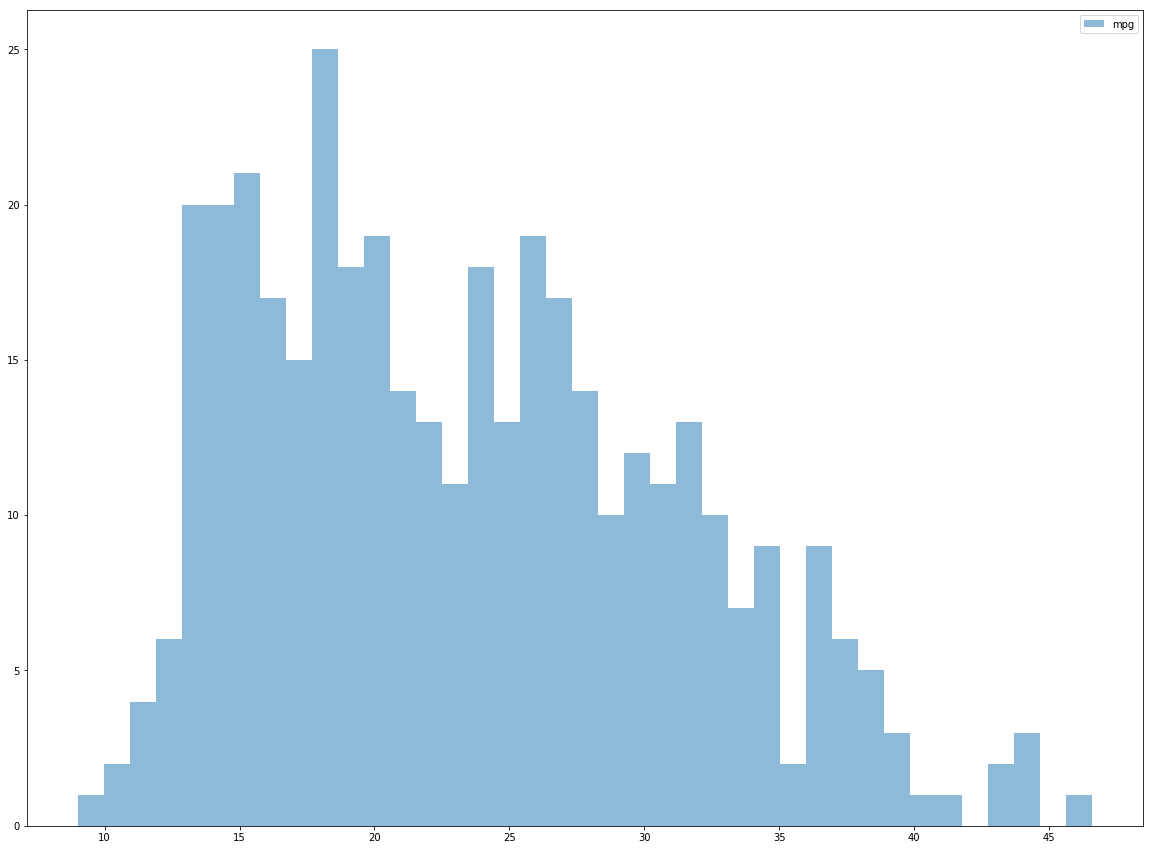

In [554]:
#Now call this function on the original dataframe above
#The below histograms further reveals, the levels, ranges and multi modal nature of different 
#features.
show_quant_feature_hist_plot(cars_mpg_df)

Text(0.5, 1.0, 'Before Scaling')

Text(0.5, 1.0, 'After Standard Scaler')

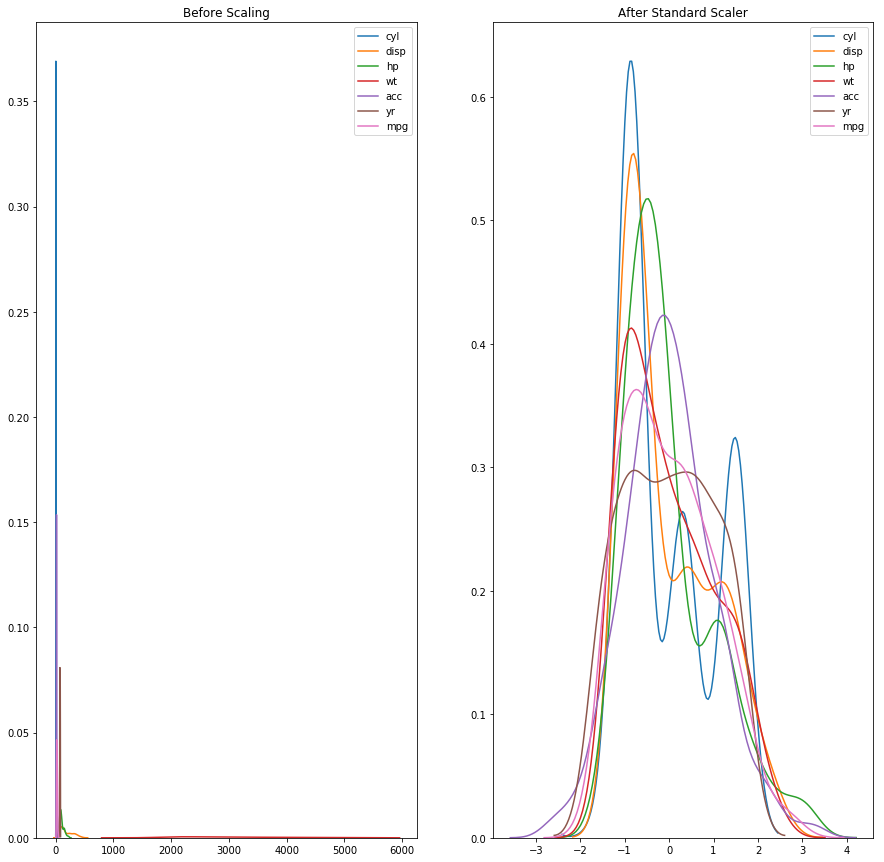

In [555]:
#Apart from individual histogram (or bar chart in case of categorical variables above), we also
#want to see the z-score plot to find the range of z-scores and shapes of distributions in a common
#scale..so here goes a before/after stdScaling distribution:
from sklearn import preprocessing
descr_trans_df = cars_mpg_df.describe()
scaler = preprocessing.StandardScaler()
scaled_X = scaler.fit_transform(cars_mpg_df[list(descr_trans_df.T.index)])
scaled_X = pd.DataFrame(scaled_X, columns=list(descr_trans_df.T.index))
fig, (ax1, ax2) = pyplot.subplots(ncols=2, figsize=(15, 15))
ax1.set_title('Before Scaling')
for i in list(descr_trans_df.T.index)[0:8]:#7 features present here
    sns.kdeplot(cars_mpg_df[i], ax=ax1)
ax2.set_title('After Standard Scaler')
for i in list(descr_trans_df.T.index)[0:8]:#7 features present here
    sns.kdeplot(scaled_X[i], ax=ax2)
pyplot.show()

(<Figure size 1080x720 with 1 Axes>,
 <matplotlib.axes._subplots.AxesSubplot at 0x24b95495cf8>)

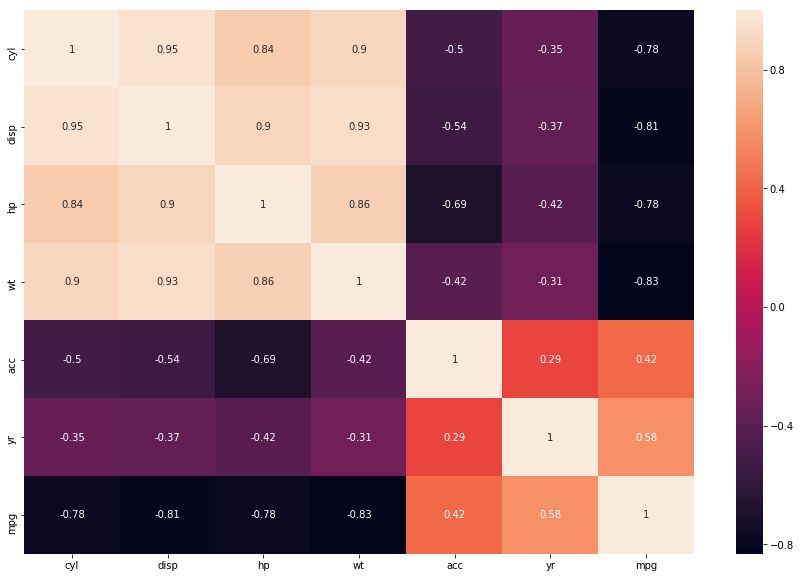

In [556]:
#Now it is required to get a quant+ visual sense of the correlation matrix to find the 
#highly correlated "almost aproaching white patches" as well!
pyplot.subplots(figsize=(15,10))
sns.heatmap(cars_mpg_df.corr(), annot=True)

*After looking into the off-diagonal panels on the pair-plot and the correlation heatmap, we find that the
feature space suffer with multi-collinearity and before taking a decision to boost the SNR(signal to noise ratio)
to achive better clusters using PCA, we would further want to look at the Variance Inflation Factor scores for
each column...if they are > 5-10, we better decide to make the cluster using the PCA features.*

In [557]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [558]:
cars_mpg_df_mat = cars_mpg_df.as_matrix()
cars_mpg_df_mat.shape

(392, 7)

In [559]:
vif = [ variance_inflation_factor( cars_mpg_df_mat, i ) for i in range( cars_mpg_df_mat.shape[1] ) ]

In [560]:
vif

[116.73347001464944,
 86.91472263358838,
 60.71138712476319,
 170.49174168660284,
 69.45767346473933,
 290.86014954404766,
 51.428134668538064]

In [561]:
vif_factors = pd.DataFrame()
vif_factors['column'] = list(cars_mpg_df.columns)
vif_factors['vif'] = vif
vif_factors

,column,vif
0,cyl,116.733470
1,disp,86.914723
2,hp,60.711387
3,wt,170.491742
4,acc,69.457673
5,yr,290.860150
6,mpg,51.428135


*Above clears any remaining doubts to go for PCA or not first...we surely would do better to convert to PCA features,
as the vif for each column is way too high*

*Now we will start preparations for PCA, which includes as a first step, to do a std-scaling first... and a quick look into
the distributions and pairplots again...though the original distributions have already been looked at, but no harm
looking additionally with the scaled dist*

In [562]:
#Initially, I thought of including this step to "remove" the outliers (rather than replacing them with median for example)
#as PCA is supposed to be sensitive to outliers, but going thru this approach fully is not resulting in better results
#hence not including this step any more.
#from scipy import stats
#cars_mpg_df = cars_mpg_df[(np.abs(stats.zscore(cars_mpg_df)) < 2.5).all(axis=1)]

In [563]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
scaled_cars_mpg_df = pd.DataFrame(scaler.fit_transform(cars_mpg_df.values), columns=cars_mpg_df.columns, index=cars_mpg_df.index)

In [564]:
scaled_cars_mpg_df.to_excel("./scaled_data.xlsx")

In [565]:
scaled_cars_mpg_df.sample(n=8, random_state=2)

,cyl,disp,hp,wt,acc,yr,mpg
55,-0.864014,-0.989490,-0.896659,-1.205425,1.799657,-1.353505,0.327654
70,-1.451004,-1.190426,-0.194303,-0.763374,-0.740861,-1.081695,-0.570352
313,-0.864014,-0.415384,-0.376395,0.029960,1.654485,1.092789,0.109567
179,-0.864014,-0.989490,-1.338883,-1.394033,0.710864,-0.266263,1.225661
307,-0.864014,-0.922511,-0.740580,-0.982631,-0.305344,1.092789,2.316097
324,-0.864014,-0.999058,-1.468949,-0.757480,2.961037,1.092789,2.559841
380,0.309967,-0.128332,0.143869,-0.038410,0.311639,1.636410,0.199368
108,-0.864014,-0.520637,-0.844632,-0.679679,1.436726,-0.809884,-0.313779


In [566]:
scaled_cars_mpg_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cyl,392.0,-1.699321e-16,1.001278,-1.451004,-0.864014,-0.864014,1.483947,1.483947
disp,392.0,-2.537653e-16,1.001278,-1.209563,-0.855532,-0.415384,0.778276,2.493416
hp,392.0,-4.392745e-16,1.001278,-1.520975,-0.766593,-0.285349,0.560080,3.265452
wt,392.0,5.607759e-17,1.001278,-1.608575,-0.886854,-0.205211,0.751093,2.549061
acc,392.0,6.117555e-16,1.001278,-2.736983,-0.641055,-0.014999,0.538471,3.360262
yr,392.0,-9.754102e-16,1.001278,-1.625315,-0.809884,0.005547,0.820978,1.636410
mpg,392.0,-1.840931e-16,1.001278,-1.853218,-0.826925,-0.089277,0.712514,2.970359


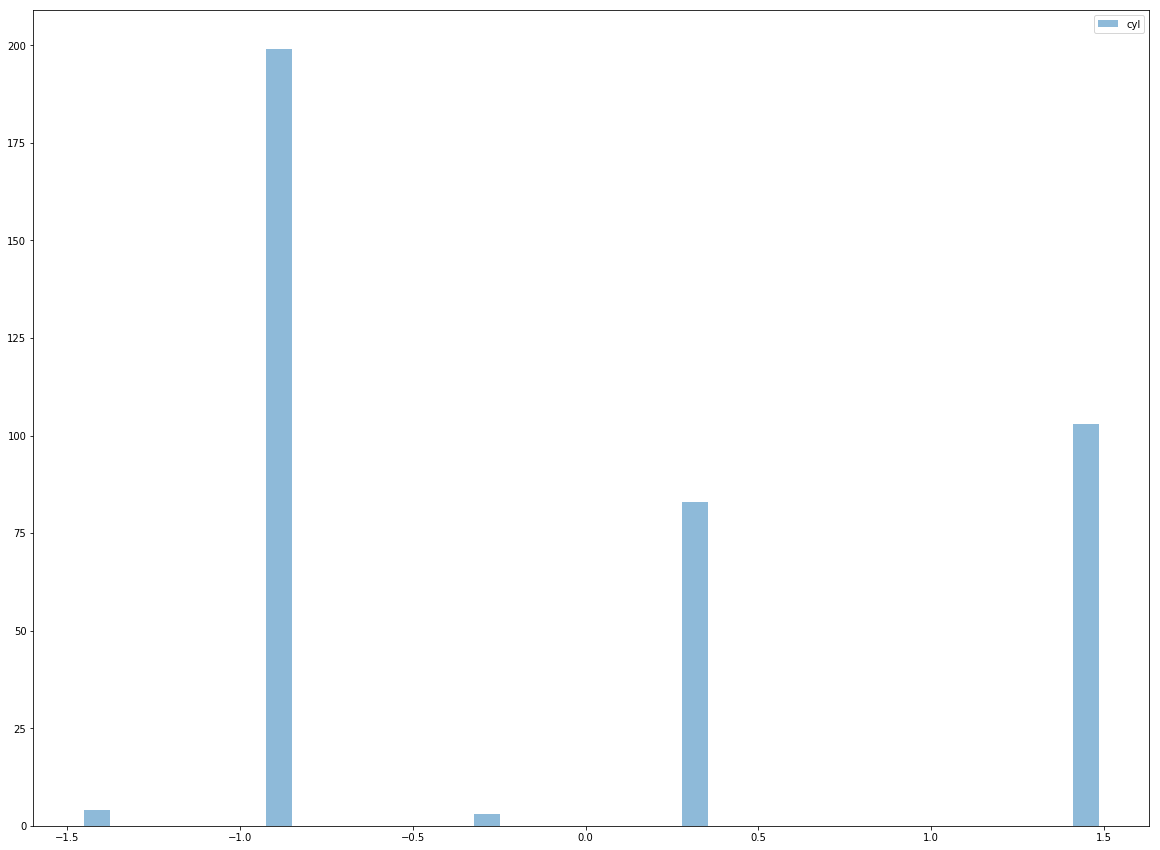

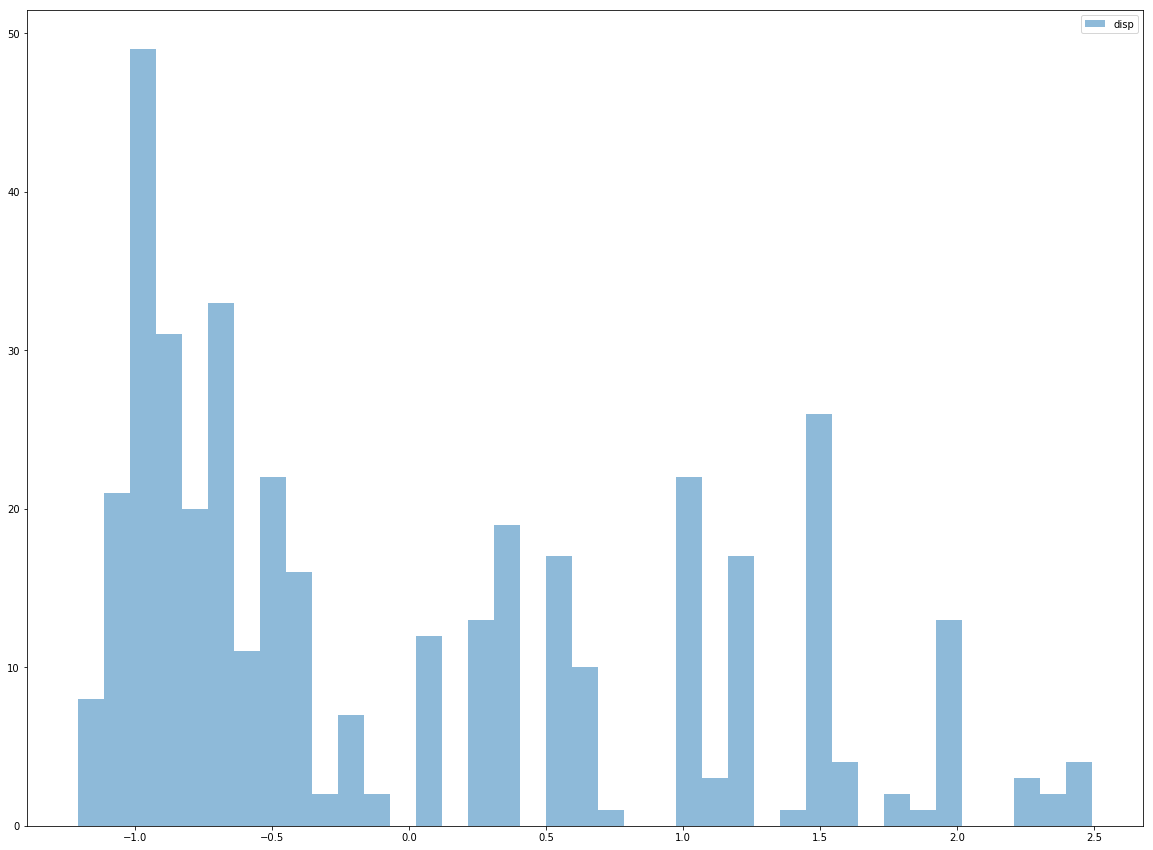

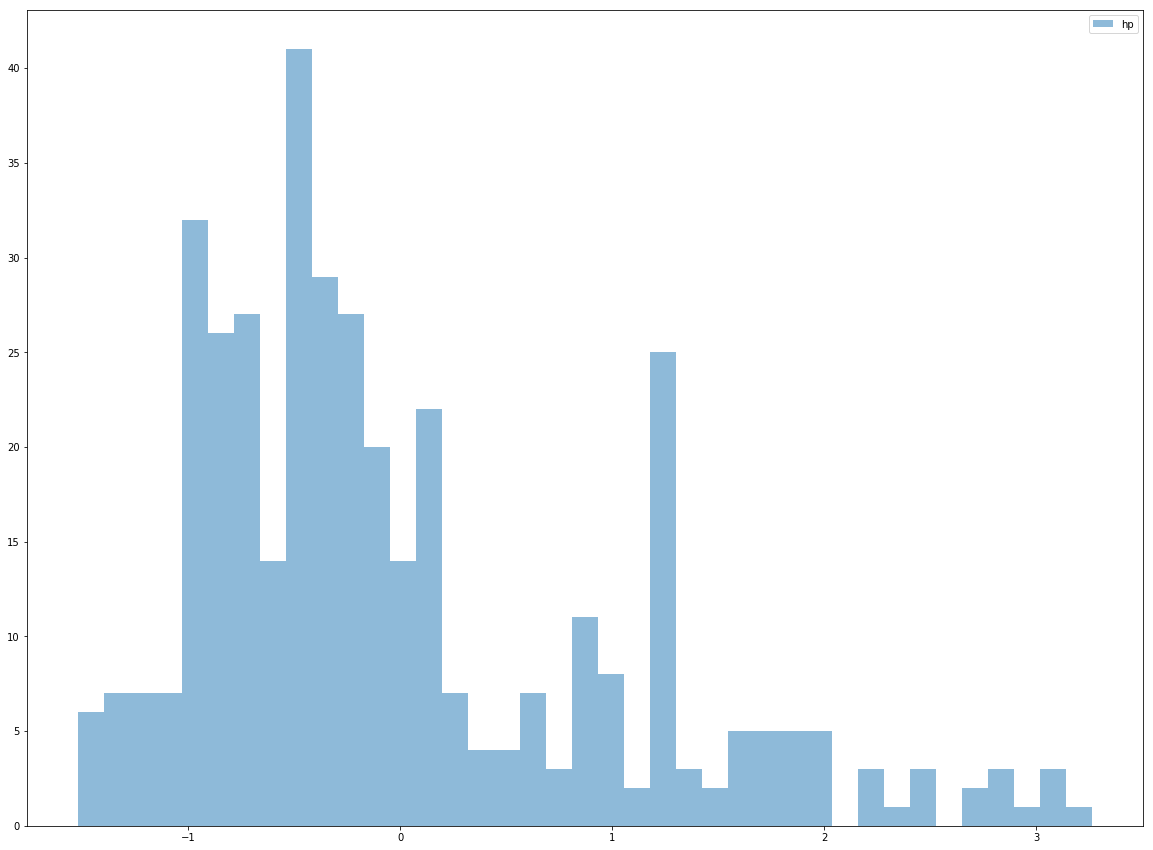

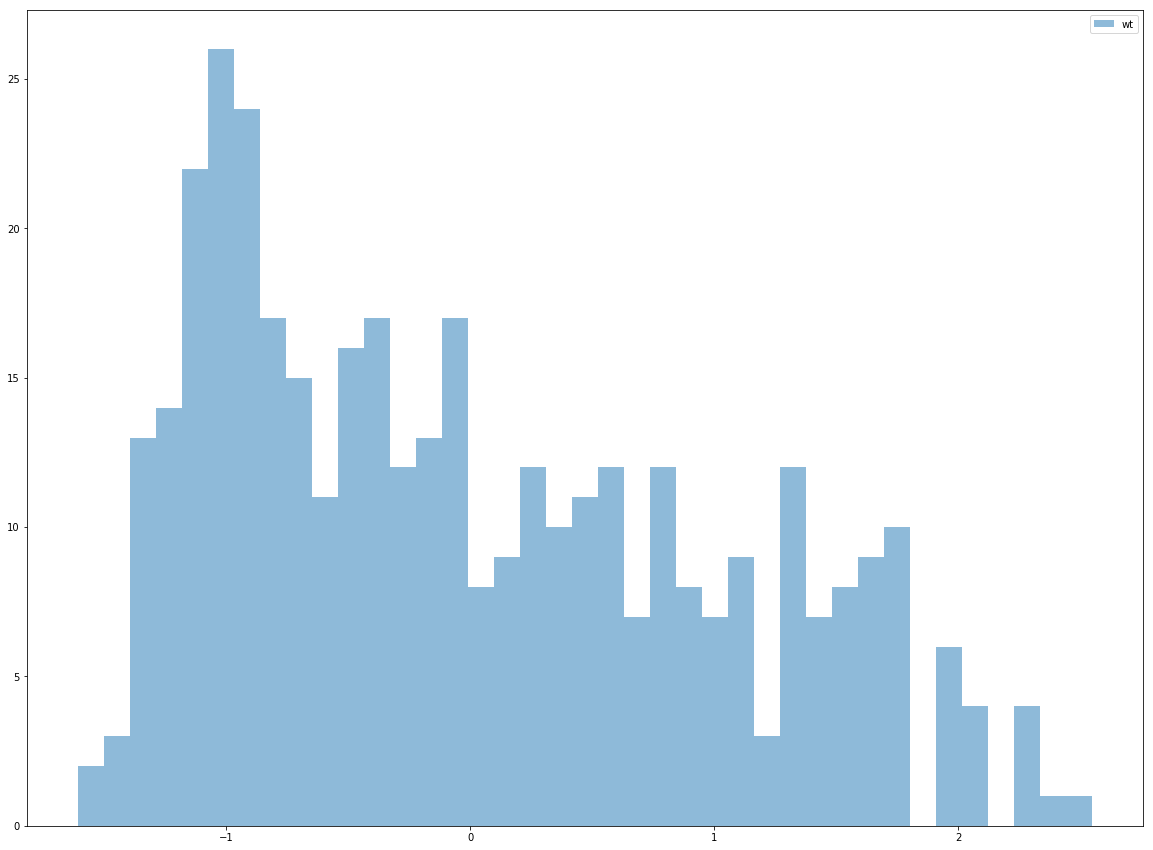

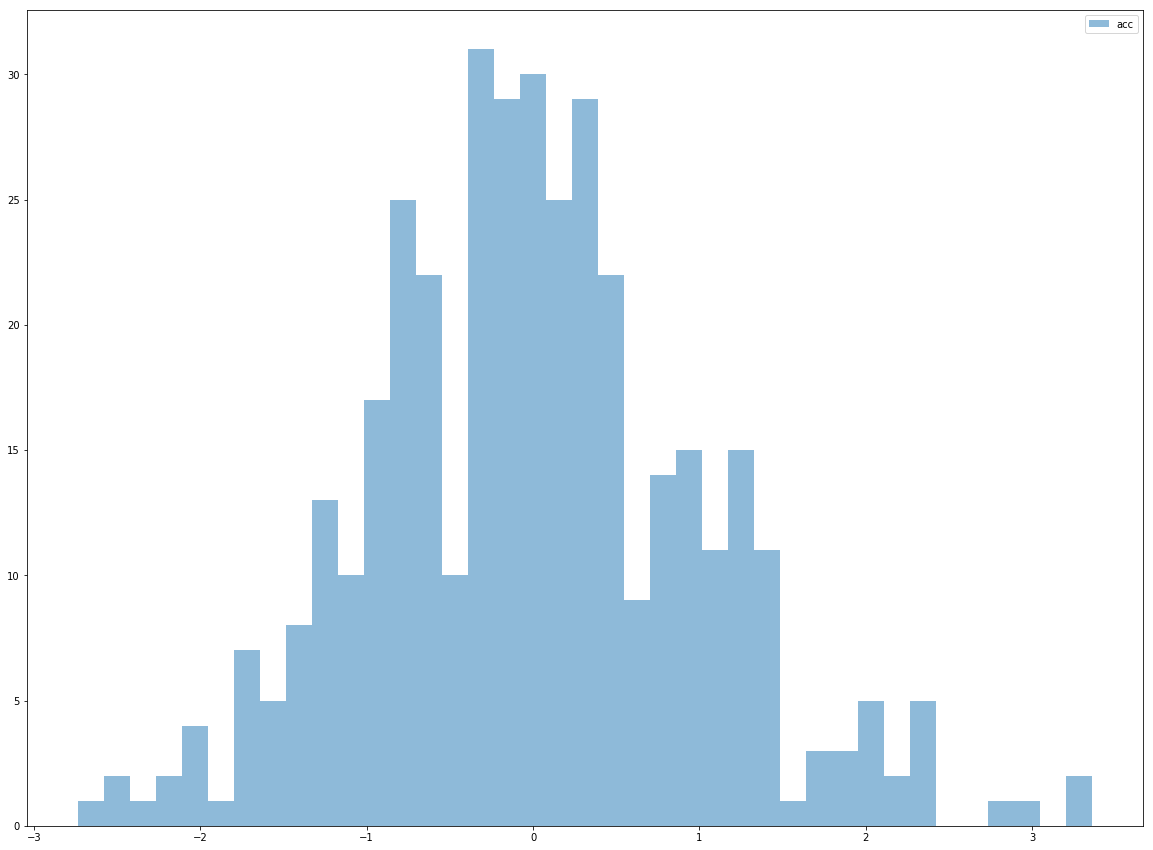

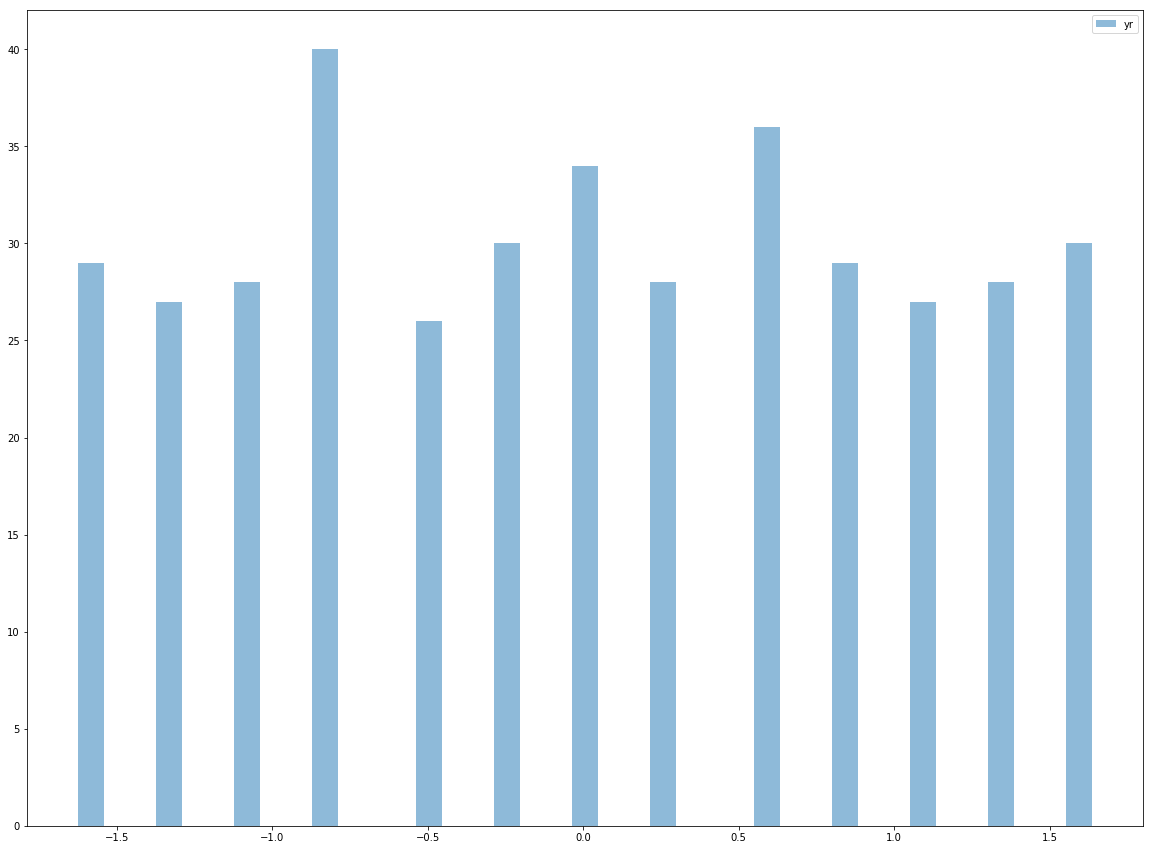

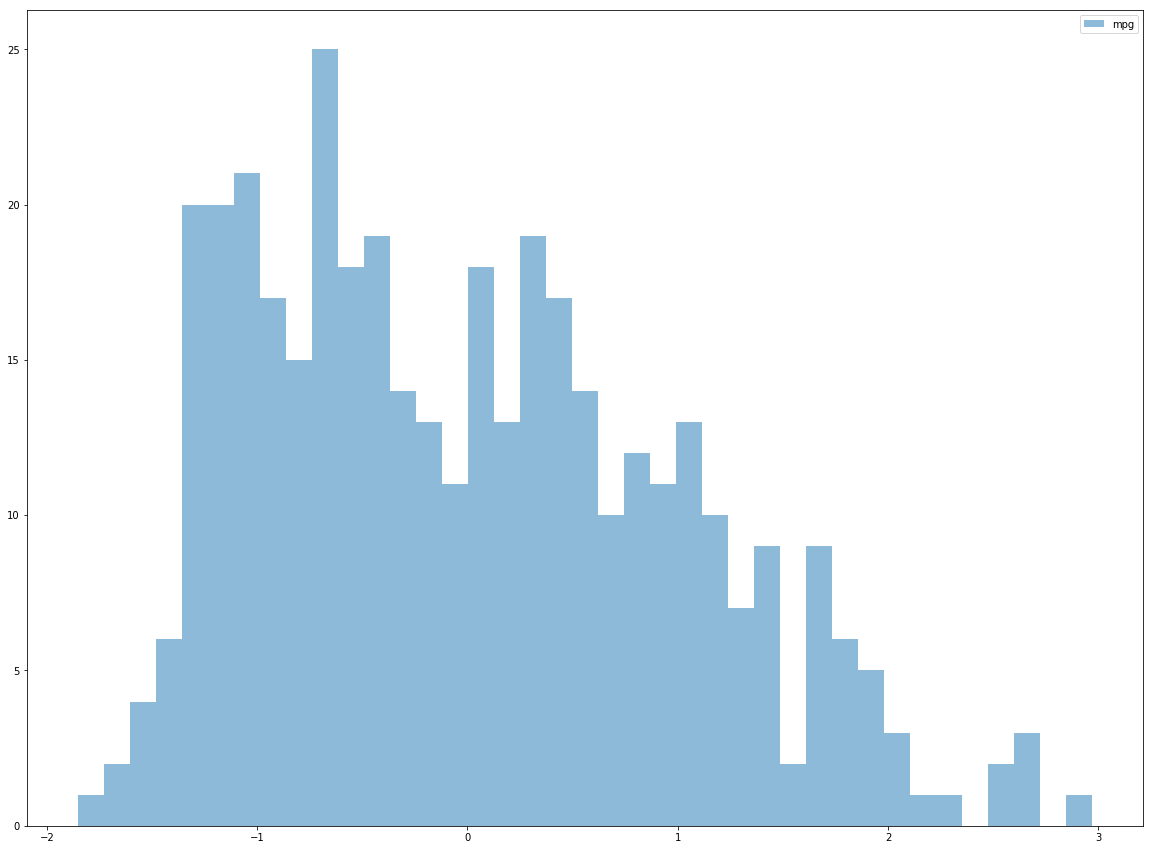

In [567]:
show_quant_feature_hist_plot(scaled_cars_mpg_df)

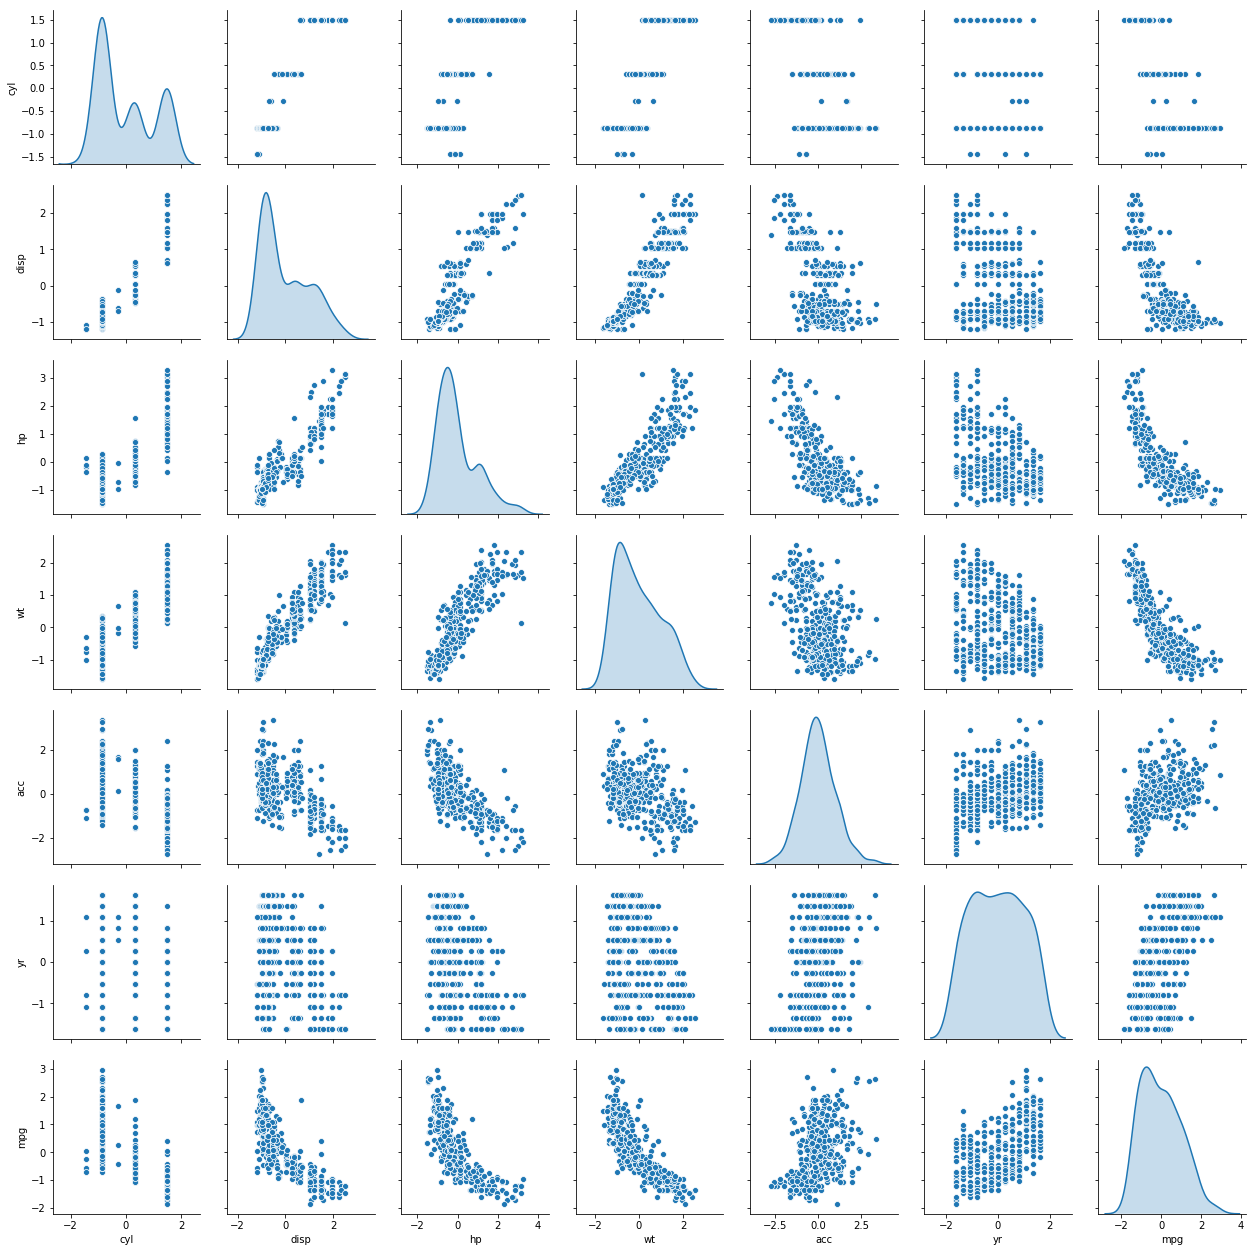

In [568]:
sns.pairplot(scaled_cars_mpg_df, diag_kind='kde')

*Now with std-scaling done, we proceed for the next set of steps for obtaining PCA featureset...here goes*

In [569]:
cov_matrix = np.cov(scaled_cars_mpg_df.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[ 1.00255754  0.95325507  0.84513932  0.89982281 -0.50597413 -0.34653145
  -0.7796063 ]
 [ 0.95325507  1.00255754  0.89955178  0.93538058 -0.54519129 -0.37080113
  -0.80718609]
 [ 0.84513932  0.89955178  1.00255754  0.86674883 -0.69095816 -0.41742634
  -0.78041765]
 [ 0.89982281  0.93538058  0.86674883  1.00255754 -0.41790529 -0.30991047
  -0.83437272]
 [-0.50597413 -0.54519129 -0.69095816 -0.41790529  1.00255754  0.29105861
   0.42441122]
 [-0.34653145 -0.37080113 -0.41742634 -0.30991047  0.29105861  1.00255754
   0.58202573]
 [-0.7796063  -0.80718609 -0.78041765 -0.83437272  0.42441122  0.58202573
   1.00255754]]


In [570]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.41612416 -0.19854113  0.13915928  0.47730649  0.49322226 -0.43171605
   0.3325483 ]
 [-0.42928265 -0.18036242  0.1003161   0.29784705  0.05658084  0.81287676
  -0.14296713]
 [-0.42281287 -0.08524183 -0.16968441 -0.04207625 -0.71128893 -0.06438539
   0.52280252]
 [-0.41404571 -0.22467457  0.27610337 -0.10773508 -0.26515768 -0.36715386
  -0.69651778]
 [ 0.28489711  0.00697163  0.89330772  0.12112398 -0.23075501  0.05279944
   0.22378488]
 [ 0.22951004 -0.9096748  -0.03724635 -0.30243525  0.08896075  0.05113155
   0.12819545]
 [ 0.39813476 -0.20675864 -0.25721494  0.75096624 -0.34077556 -0.09221162
  -0.20975889]]

 Eigen Values 
%s [5.02345075 0.86780518 0.73025667 0.18438547 0.12222813 0.03538069
 0.05439593]


<BarContainer object of 7 artists>

Text(0, 0.5, 'Explained variance ratio')

Text(0.5, 0, 'Principal components')

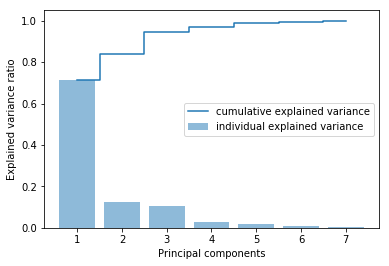

In [571]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 7entries as there are 7 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 7 entries with 7 th entry 
# cumulative reaching almost 100%

pyplot.bar(range(1,8), var_explained, alpha=0.5, align='center', label='individual explained variance')
pyplot.step(range(1,8),cum_var_exp, where= 'mid', label='cumulative explained variance')
pyplot.ylabel('Explained variance ratio')
pyplot.xlabel('Principal components')
pyplot.legend(loc = 'best')
pyplot.show()

In [572]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(5.023450750382196, array([-0.41612416, -0.42928265, -0.42281287, -0.41404571,  0.28489711,
        0.22951004,  0.39813476])), (0.8678051844996096, array([-0.19854113, -0.18036242, -0.08524183, -0.22467457,  0.00697163,
       -0.9096748 , -0.20675864])), (0.7302566706735846, array([ 0.13915928,  0.1003161 , -0.16968441,  0.27610337,  0.89330772,
       -0.03724635, -0.25721494])), (0.1843854652553802, array([ 0.47730649,  0.29784705, -0.04207625, -0.10773508,  0.12112398,
       -0.30243525,  0.75096624])), (0.12222813011294921, array([ 0.49322226,  0.05658084, -0.71128893, -0.26515768, -0.23075501,
        0.08896075, -0.34077556])), (0.05439592634122041, array([ 0.3325483 , -0.14296713,  0.52280252, -0.69651778,  0.22378488,
        0.12819545, -0.20975889])), (0.03538068603429337, array([-0.43171605,  0.81287676, -0.06438539, -0.36715386,  0.05279944,
        0.05113155, -0.09221162]))]
Eigenvalues in descending order: 
[5.023450750382196, 0.8678051844996096, 0.7302566706735846, 

In [573]:
P_reduce = np.array(eigvectors_sorted[0:3])   # Reducing from 7 to 3 dimension space
X_std_3D = np.dot(scaled_cars_mpg_df,P_reduce.T)   # projecting original data into principal component dimensions
P_reduce.shape
X_std_3D.shape

Proj_data_df = pd.DataFrame(X_std_3D)  # converting array to dataframe for pairplot
Proj_data_df.shape
#Proj_data_df['car name'] = car_names_df
#Proj_data_df = Proj_data_df.set_index('car name')

(3, 7)

(392, 3)

(392, 3)

In [574]:
Proj_data_df.sample(n=8, random_state=2)

,0,1,2
55,1.995052,1.873321,1.173613
70,0.826647,1.787616,-0.973964
313,1.450380,-0.733387,1.319315
179,2.556989,0.771095,-0.047528
307,2.561469,-0.853255,-1.267624
324,3.836696,-0.855571,1.765644
380,0.424913,-1.569678,0.161403
108,1.320093,1.301774,1.177508


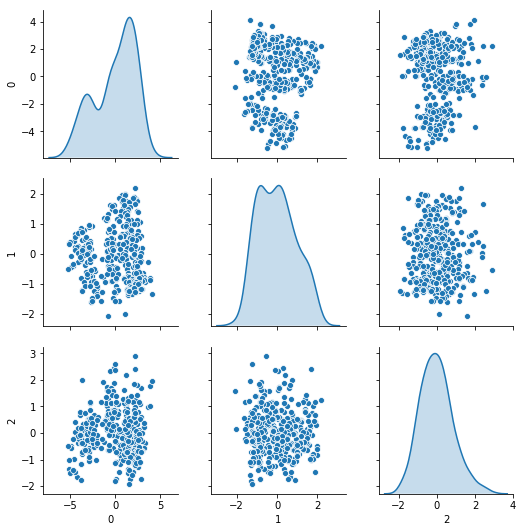

In [575]:
sns.pairplot(Proj_data_df, diag_kind='kde') 

## Question 3

Use K Means or Hierarchical clustering to find out the optimal number of clusters in the data. Identify and separate the clusters (10 points)

In [576]:
from sklearn.cluster import KMeans

In [577]:
cluster_range = range( 2, 16)   # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 6
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(Proj_data_df)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
clusters_df[0:15]

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=2, n_init=5, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=3, n_init=5, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=4, n_init=5, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=5, n_init=5, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=6, n_init=5, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

...

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=12, n_init=5, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=13, n_init=5, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=14, n_init=5, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=15, n_init=5, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

,num_clusters,cluster_errors
0,2,1120.558944
1,3,783.819856
2,4,584.685307
3,5,518.088127
4,6,463.127443
5,7,408.703515
6,8,365.743851
7,9,345.845507
8,10,303.139527
9,11,284.031479


<Figure size 864x432 with 0 Axes>

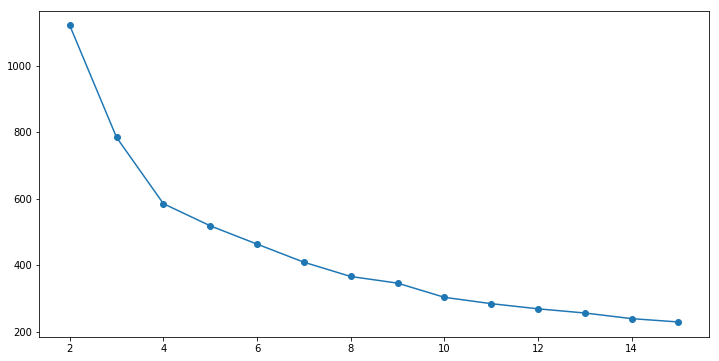

In [578]:
# Elbow plot

pyplot.figure(figsize=(12,6))
pyplot.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

In [579]:
#above, the number 4 seems to be a better "kinked" hence choosing this as "num of clusters"
cluster = KMeans( n_clusters = 4, random_state = 2354 )
cluster.fit(Proj_data_df)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=4, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=2354, tol=0.0001, verbose=0)

In [580]:
centroids = cluster.cluster_centers_
centroids

array([[ 1.23425287,  1.10515033, -0.10348621],
       [-3.39370987, -0.15163643, -0.1538647 ],
       [-0.50184414, -0.20474286,  0.59500255],
       [ 2.1866313 , -0.68314228, -0.25540808]])

In [581]:
prediction=cluster.predict(Proj_data_df)
Proj_data_df['car name'] = car_names_df['car name']
Proj_data_df["GROUP"] = prediction
Proj_data_df.to_excel("./cars_mpg_usable_clustered4_PCA.xlsx")

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000024BA2F08710>,
      dtype=object)

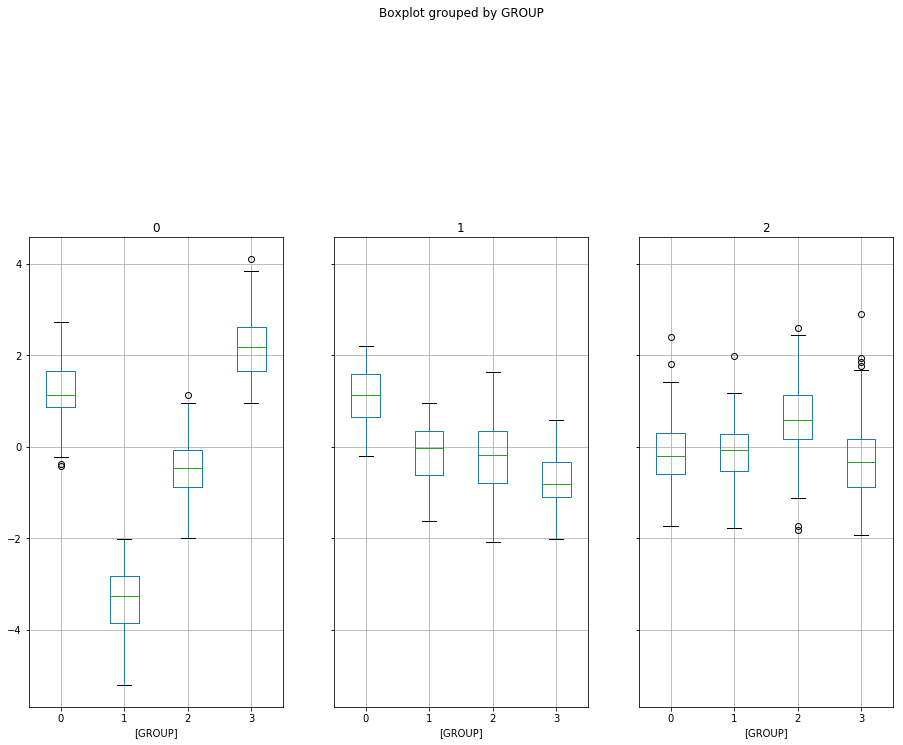

In [582]:
import matplotlib.pylab as plt
Proj_data_df.boxplot(by = 'GROUP',  layout=(4,3), figsize=(15, 40))

In [583]:
Proj_data_df.groupby("GROUP").count()

,0,1,2,car name
GROUP,,,,
0,98,98,98,98
1,94,94,94,94
2,89,89,89,89
3,111,111,111,111


In [584]:
Proj_data_df.sample(n=8, random_state=2)

,0,1,2,car name,GROUP
55,1.995052,1.873321,1.173613,plymouth cricket,0
70,0.826647,1.787616,-0.973964,mazda rx2 coupe,0
313,1.450380,-0.733387,1.319315,amc concord,3
179,2.556989,0.771095,-0.047528,honda civic cvcc,0
307,2.561469,-0.853255,-1.267624,vw rabbit,3
324,3.836696,-0.855571,1.765644,vw dasher (diesel),3
380,0.424913,-1.569678,0.161403,buick century limited,2
108,1.320093,1.301774,1.177508,chevrolet vega,0


In [585]:
#Now keeping the 'car name' has served its purpose and can't be taken furhter
#in order to merge the GROUP here back to the original car dataframe, as the
#'car name' has duplicate names, owing to the fact that a car for example
#honda civic can have a another year model also listed (with probably different 
#upgraded/downgraded specs)..hence reseting the index
#Proj_data_df.reset_index(inplace=True)
Proj_data_df.sample(n=8, random_state=2)
Proj_data_df.head()
Proj_data_df.shape

,0,1,2,car name,GROUP
55,1.995052,1.873321,1.173613,plymouth cricket,0
70,0.826647,1.787616,-0.973964,mazda rx2 coupe,0
313,1.450380,-0.733387,1.319315,amc concord,3
179,2.556989,0.771095,-0.047528,honda civic cvcc,0
307,2.561469,-0.853255,-1.267624,vw rabbit,3
324,3.836696,-0.855571,1.765644,vw dasher (diesel),3
380,0.424913,-1.569678,0.161403,buick century limited,2
108,1.320093,1.301774,1.177508,chevrolet vega,0


,0,1,2,car name,GROUP
0,-2.635049,0.929039,-0.534679,chevrolet chevelle malibu,1
1,-3.493800,0.805473,-0.649495,buick skylark 320,1
2,-2.970415,0.881186,-0.958742,plymouth satellite,1
3,-2.910197,0.961721,-0.582953,amc rebel sst,1
4,-2.903826,0.952789,-1.054836,ford torino,1


(392, 5)

In [586]:
cars_mpg_df.sample(n=8, random_state=2)
cars_mpg_df.head()
cars_mpg_df_int.head()
cars_mpg_df_int.shape

,cyl,disp,hp,wt,acc,yr,mpg
55,4,91.0,70.0,1955,20.5,71,26.0
70,3,70.0,97.0,2330,13.5,72,19.0
313,4,151.0,90.0,3003,20.1,80,24.3
179,4,91.0,53.0,1795,17.5,75,33.0
307,4,98.0,76.0,2144,14.7,80,41.5
324,4,90.0,48.0,2335,23.7,80,43.4
380,6,181.0,110.0,2945,16.4,82,25.0
108,4,140.0,72.0,2401,19.5,73,21.0


,cyl,disp,hp,wt,acc,yr,mpg
0,8,307.0,130.0,3504,12.0,70,18.0
1,8,350.0,165.0,3693,11.5,70,15.0
2,8,318.0,150.0,3436,11.0,70,18.0
3,8,304.0,150.0,3433,12.0,70,16.0
4,8,302.0,140.0,3449,10.5,70,17.0


,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130.0,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165.0,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150.0,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150.0,3433,12.0,70,16.0
4,ford torino,8,302.0,140.0,3449,10.5,70,17.0


(392, 8)

In [587]:
#This is the crucial step where the GROUP info acquired
#thru PCA -> Clustering step is ported back to the 
#original usable dataframe(cars_mpg_df_int).Which can be
#preferably #saved as well, in form of a csv/xls.So that,
#we can in turn use them to doa GROUP-by linear-regression
#excercise.cars_mpg_df_int & cars_mpg_df are similar in all
#respects apart from the fact that 'car name' is preserved 
#as an extra column.This info can be used to validate few
#car samples manually, based on wikipedia search for those
#models.
cars_mpg_df['car name'] = car_names_df['car name']
cars_mpg_df['GROUP'] = Proj_data_df['GROUP']

In [588]:
cars_mpg_df.sample(n=8, random_state=2)
cars_mpg_df.to_excel("./cars_mpg_usable_clustered4.xlsx")
#Would be uploading this xls as well for refr. to github
#For example, if I sort this xls for mpg, from largest to smallest,
# can see that the GROUP-3 with the highest mpg, as shown in the boxplot
#in the below cell appears at hte top...GROUP-1 appears at hte bottom
#(again as is shown in the boxplot)...also from the same mpg box plot
#i can see that the +ve outlier from the GROUP 0 (one bubble at the 
#top of GROUP 0 from mpg boxplot below, appears as "datsun1200" as appearing in the 
#sorted xls sheet)

,cyl,disp,hp,wt,acc,yr,mpg,car name,GROUP
55,4,91.0,70.0,1955,20.5,71,26.0,plymouth cricket,0
70,3,70.0,97.0,2330,13.5,72,19.0,mazda rx2 coupe,0
313,4,151.0,90.0,3003,20.1,80,24.3,amc concord,3
179,4,91.0,53.0,1795,17.5,75,33.0,honda civic cvcc,0
307,4,98.0,76.0,2144,14.7,80,41.5,vw rabbit,3
324,4,90.0,48.0,2335,23.7,80,43.4,vw dasher (diesel),3
380,6,181.0,110.0,2945,16.4,82,25.0,buick century limited,2
108,4,140.0,72.0,2401,19.5,73,21.0,chevrolet vega,0


In [589]:
from scipy.stats import zscore

In [590]:
cars_mpg_df_int1 = cars_mpg_df[['cyl','disp', 'hp','wt', 'acc', 'yr', 'mpg']].apply(zscore)

In [591]:
cars_mpg_df_int1['GROUP'] = cars_mpg_df['GROUP']

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000024BA3D9B828>,
      dtype=object)

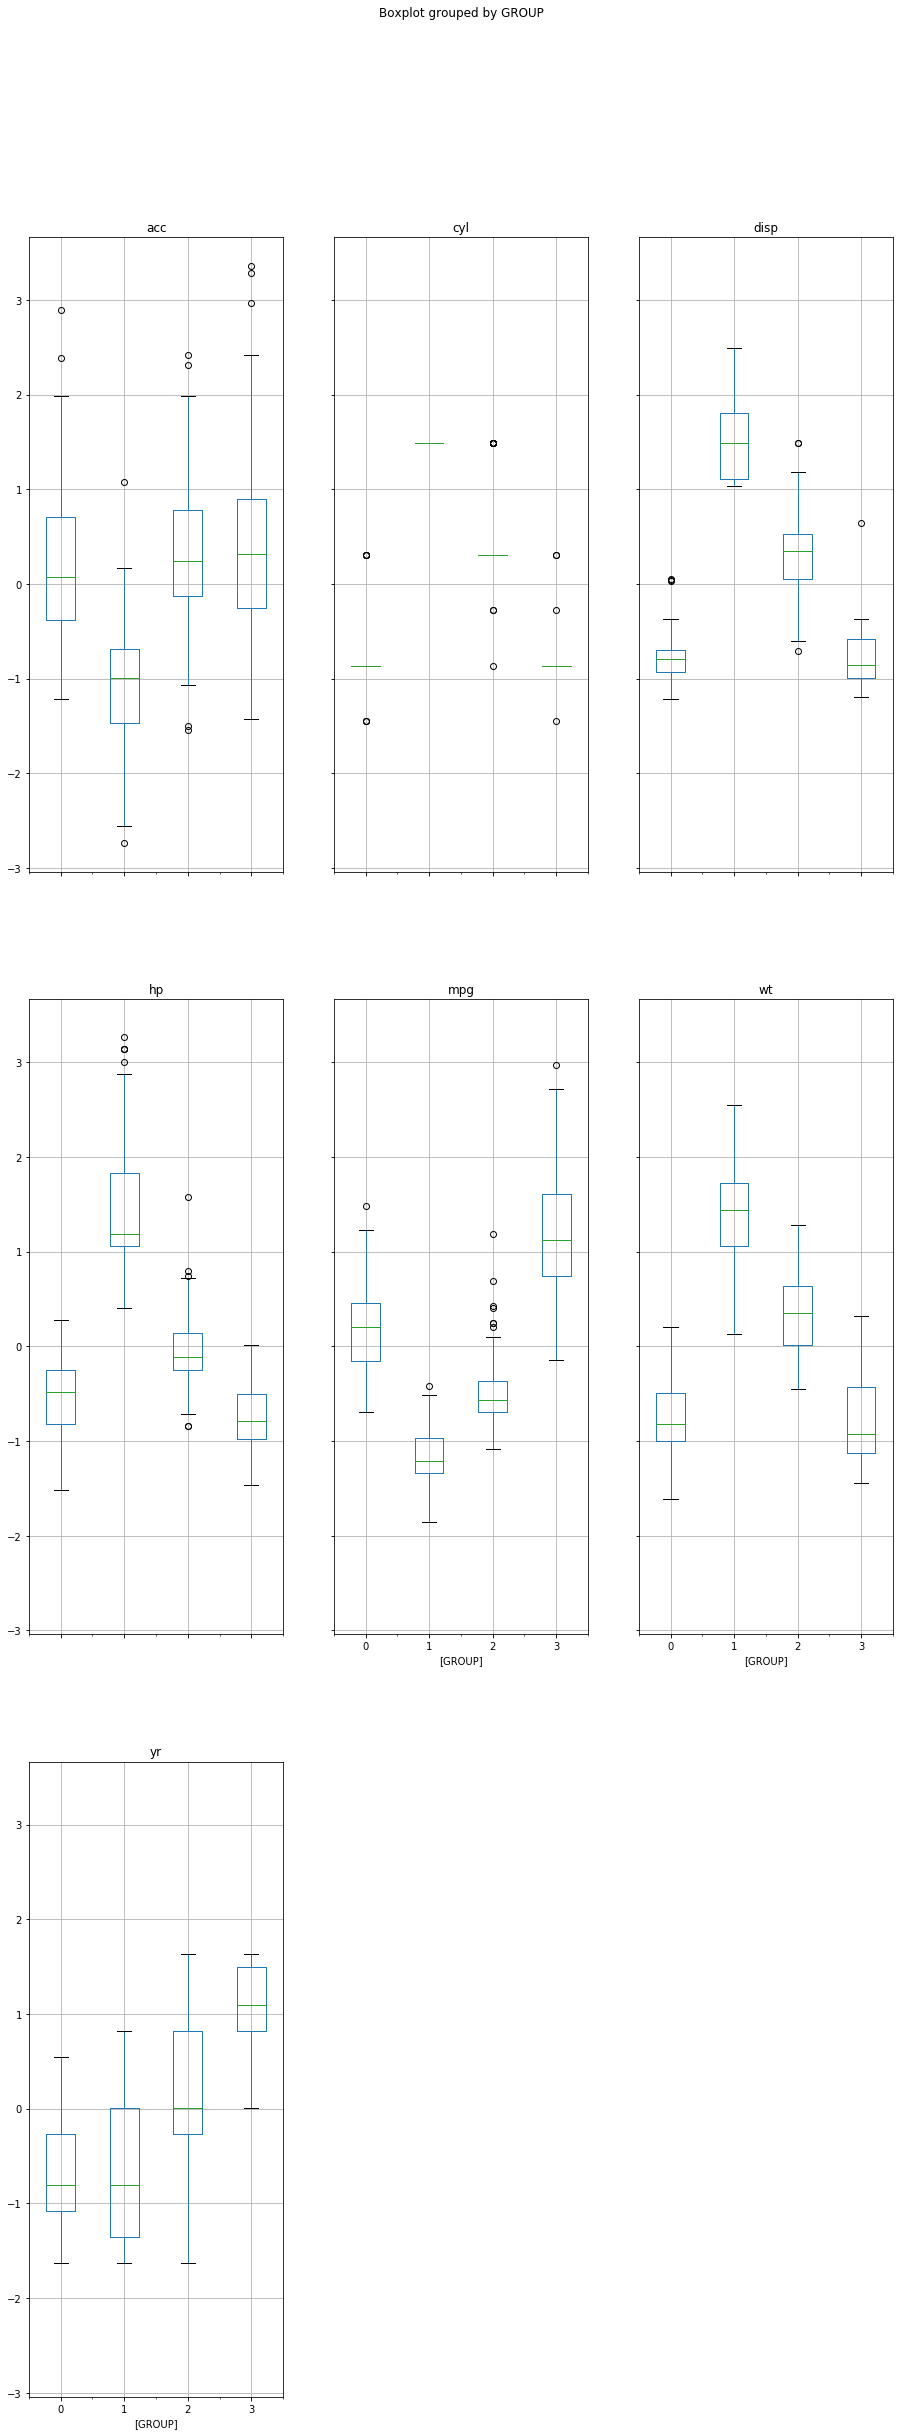

In [592]:
cars_mpg_df_int1.boxplot(by = 'GROUP',  layout=(3,3), figsize=(15, 40))

In [623]:
df = pd.read_excel("./cars_mpg_usable_clustered4.xlsx")
df.reset_index(inplace=True, drop=True)
cars_mpg_clustered_df = df.loc[:,['cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'mpg', 'GROUP']]
cars_mpg_clustered_df.sample(n=8, random_state=2)

,cyl,disp,hp,wt,acc,yr,mpg,GROUP
55,4,91.0,70,1955,20.5,71,26.0,0
70,3,70.0,97,2330,13.5,72,19.0,0
313,4,151.0,90,3003,20.1,80,24.3,3
179,4,91.0,53,1795,17.5,75,33.0,0
307,4,98.0,76,2144,14.7,80,41.5,3
324,4,90.0,48,2335,23.7,80,43.4,3
380,6,181.0,110,2945,16.4,82,25.0,2
108,4,140.0,72,2401,19.5,73,21.0,0


In [624]:
#Get the dataframe under GROUP-0
car_mpg_GROUP_0 = cars_mpg_clustered_df[cars_mpg_clustered_df['GROUP']==0]
car_mpg_GROUP_0.head()
#Now drop the GROUP0 coulumn
car_mpg_GROUP_0 = car_mpg_GROUP_0.drop('GROUP', axis=1)
car_mpg_GROUP_0.head()

,cyl,disp,hp,wt,acc,yr,mpg,GROUP
14,4,113.0,95,2372,15.0,70,24.0,0
15,6,198.0,95,2833,15.5,70,22.0,0
17,6,200.0,85,2587,16.0,70,21.0,0
18,4,97.0,88,2130,14.5,70,27.0,0
19,4,97.0,46,1835,20.5,70,26.0,0


,cyl,disp,hp,wt,acc,yr,mpg
14,4,113.0,95,2372,15.0,70,24.0
15,6,198.0,95,2833,15.5,70,22.0
17,6,200.0,85,2587,16.0,70,21.0
18,4,97.0,88,2130,14.5,70,27.0
19,4,97.0,46,1835,20.5,70,26.0


In [625]:
#Get the dataframe under GROUP-1
car_mpg_GROUP_1 = cars_mpg_clustered_df[cars_mpg_clustered_df['GROUP']==1]
car_mpg_GROUP_1.head()
#Now drop the GROUP1 coulumn
car_mpg_GROUP_1 = car_mpg_GROUP_1.drop('GROUP', axis=1)
car_mpg_GROUP_1.head()

,cyl,disp,hp,wt,acc,yr,mpg,GROUP
0,8,307.0,130,3504,12.0,70,18.0,1
1,8,350.0,165,3693,11.5,70,15.0,1
2,8,318.0,150,3436,11.0,70,18.0,1
3,8,304.0,150,3433,12.0,70,16.0,1
4,8,302.0,140,3449,10.5,70,17.0,1


,cyl,disp,hp,wt,acc,yr,mpg
0,8,307.0,130,3504,12.0,70,18.0
1,8,350.0,165,3693,11.5,70,15.0
2,8,318.0,150,3436,11.0,70,18.0
3,8,304.0,150,3433,12.0,70,16.0
4,8,302.0,140,3449,10.5,70,17.0


In [626]:
#Get the dataframe under GROUP-2
car_mpg_GROUP_2 = cars_mpg_clustered_df[cars_mpg_clustered_df['GROUP']==2]
car_mpg_GROUP_2.head()
#Now drop the GROUP2 coulumn
car_mpg_GROUP_2 = car_mpg_GROUP_2.drop('GROUP', axis=1)
car_mpg_GROUP_2.head()

,cyl,disp,hp,wt,acc,yr,mpg,GROUP
16,6,199.0,97,2774,15.5,70,18.0,2
32,6,232.0,100,2634,13.0,71,19.0,2
33,6,225.0,105,3439,15.5,71,16.0,2
34,6,250.0,100,3329,15.5,71,17.0,2
35,6,250.0,88,3302,15.5,71,19.0,2


,cyl,disp,hp,wt,acc,yr,mpg
16,6,199.0,97,2774,15.5,70,18.0
32,6,232.0,100,2634,13.0,71,19.0
33,6,225.0,105,3439,15.5,71,16.0
34,6,250.0,100,3329,15.5,71,17.0
35,6,250.0,88,3302,15.5,71,19.0


In [627]:
#Get the dataframe under GROUP-3
car_mpg_GROUP_3 = cars_mpg_clustered_df[cars_mpg_clustered_df['GROUP']==3]
car_mpg_GROUP_3.head()
#Now drop the GROUP3 coulumn
car_mpg_GROUP_3 = car_mpg_GROUP_3.drop('GROUP', axis=1)
car_mpg_GROUP_3.head()

,cyl,disp,hp,wt,acc,yr,mpg,GROUP
193,4,85.0,52,2035,22.2,76,29.0,3
196,4,91.0,53,1795,17.4,76,33.0,3
202,4,85.0,70,1990,17.0,76,32.0,3
214,4,98.0,68,2045,18.5,77,31.5,3
215,4,111.0,80,2155,14.8,77,30.0,3


,cyl,disp,hp,wt,acc,yr,mpg
193,4,85.0,52,2035,22.2,76,29.0
196,4,91.0,53,1795,17.4,76,33.0
202,4,85.0,70,1990,17.0,76,32.0
214,4,98.0,68,2045,18.5,77,31.5
215,4,111.0,80,2155,14.8,77,30.0


## Question 4

Use linear regression model on different clusters separately and print the coefficients of the models individually (10 points)

### Linear regression for GROUP-0

In [667]:
# Copy all the predictor variables into X dataframe. Since 'mpg' is dependent variable drop it
X = car_mpg_GROUP_0.drop('mpg', axis=1)
# Copy the 'mpg' column alone into the y dataframe. This is the dependent variable
y = car_mpg_GROUP_0[['mpg']]

In [668]:
#Let us break the X and y dataframes into training set and test set. For this we will use
#Sklearn package's data splitting function which is based on random function
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [677]:
# Split X and y into training and test set in 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=17)

In [678]:
X_train.shape

(78, 6)

In [679]:
X_train.head(2)

,cyl,disp,hp,wt,acc,yr
240,4,121.0,110,2600,12.8,77
118,4,114.0,91,2582,14.0,73


In [680]:
# invoke the LinearRegression function and find the bestfit model on training data
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [681]:
# Let us explore the coefficients for each of the independent attributes
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[0][idx]))

The coefficient for cyl is 1.9377883230851576
The coefficient for disp is -0.03768759874893141
The coefficient for hp is -0.0614263038504663
The coefficient for wt is -0.0050004351886246134
The coefficient for acc is -0.3012367374142273
The coefficient for yr is 0.22855889869044274


In [682]:
# Let us check the intercept for the model
intercept = regression_model.intercept_[0]
print("The intercept for our model is {}".format(intercept))

The intercept for our model is 26.188395409664107


In [683]:
regression_model.score(X_train, y_train)

0.546839171530812

In [684]:
# Model score - R2 or coeff of determinant
# R^2=1–RSS / TSS =  RegErr / TSS
regression_model.score(X_test, y_test)

0.6474381190523815

### Linear regression for GROUP-1

In [650]:
# Copy all the predictor variables into X dataframe. Since 'mpg' is dependent variable drop it
X = car_mpg_GROUP_1.drop('mpg', axis=1)
# Copy the 'mpg' column alone into the y dataframe. This is the dependent variable
y = car_mpg_GROUP_1[['mpg']]

In [659]:
# Split X and y into training and test set in 75:25 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=15)

In [660]:
X_train.shape

(75, 6)

In [661]:
X_train.head(2)

,cyl,disp,hp,wt,acc,yr
123,8,350.0,180,3664,11.0,73
285,8,351.0,138,3955,13.2,79


In [662]:
# invoke the LinearRegression function and find the bestfit model on training data
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [663]:
# Let us explore the coefficients for each of the independent attributes
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[0][idx]))

The coefficient for cyl is 0.0
The coefficient for disp is -0.007407614883008862
The coefficient for hp is -0.018436690821128057
The coefficient for wt is -0.000935024869469391
The coefficient for acc is -0.5832200443420918
The coefficient for yr is 0.36004351154315095


In [664]:
# Let us check the intercept for the model
intercept = regression_model.intercept_[0]
print("The intercept for our model is {}".format(intercept))

The intercept for our model is 4.6887477632419845


In [665]:
regression_model.score(X_train, y_train)

0.5190574727685198

In [666]:
# Model score - R2 or coeff of determinant
# R^2=1–RSS / TSS =  RegErr / TSS
regression_model.score(X_test, y_test)

0.6947869853573401

### Linear regression for GROUP-2

In [685]:
# Copy all the predictor variables into X dataframe. Since 'mpg' is dependent variable drop it
X = car_mpg_GROUP_2.drop('mpg', axis=1)
# Copy the 'mpg' column alone into the y dataframe. This is the dependent variable
y = car_mpg_GROUP_2[['mpg']]

In [702]:
# Split X and y into training and test set in 75:25 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=3)

In [703]:
X_train.shape

(71, 6)

In [704]:
X_train.head(2)

,cyl,disp,hp,wt,acc,yr
252,6,200.0,85,2965,15.8,78
125,6,232.0,100,2901,16.0,74


In [705]:
# invoke the LinearRegression function and find the bestfit model on training data
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [706]:
# Let us explore the coefficients for each of the independent attributes
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[0][idx]))

The coefficient for cyl is 0.4024920775731196
The coefficient for disp is -0.0007649458354247782
The coefficient for hp is 0.0061475736677349645
The coefficient for wt is -0.003565234298888296
The coefficient for acc is -0.13105133175547448
The coefficient for yr is 0.6007502078437156


In [707]:
# Let us check the intercept for the model
intercept = regression_model.intercept_[0]
print("The intercept for our model is {}".format(intercept))

The intercept for our model is -15.091106540720642


In [708]:
regression_model.score(X_train, y_train)

0.4677925917800919

In [709]:
# Model score - R2 or coeff of determinant
# R^2=1–RSS / TSS =  RegErr / TSS
regression_model.score(X_test, y_test)

0.48925856083383823

### Linear regression for GROUP-3

In [710]:
# Copy all the predictor variables into X dataframe. Since 'mpg' is dependent variable drop it
X = car_mpg_GROUP_3.drop('mpg', axis=1)
# Copy the 'mpg' column alone into the y dataframe. This is the dependent variable
y = car_mpg_GROUP_3[['mpg']]

In [711]:
# Split X and y into training and test set in 75:25 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=3)

In [712]:
X_train.shape

(88, 6)

In [713]:
X_train.head(2)

,cyl,disp,hp,wt,acc,yr
236,4,98.0,83,2075,15.9,77
316,4,134.0,90,2711,15.5,80


In [714]:
# invoke the LinearRegression function and find the bestfit model on training data
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [715]:
# Let us explore the coefficients for each of the independent attributes
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[0][idx]))

The coefficient for cyl is 3.961941094939954
The coefficient for disp is -0.009646412268020996
The coefficient for hp is -0.12061475198810707
The coefficient for wt is -0.006154270490086976
The coefficient for acc is 0.05415912417267465
The coefficient for yr is 0.9141293613788973


In [716]:
# Let us check the intercept for the model
intercept = regression_model.intercept_[0]
print("The intercept for our model is {}".format(intercept))

The intercept for our model is -33.20326295938889


In [717]:
regression_model.score(X_train, y_train)

0.5236554277839203

In [718]:
# Model score - R2 or coeff of determinant
# R^2=1–RSS / TSS =  RegErr / TSS
regression_model.score(X_test, y_test)

0.5722300213944422

# End Of Assignment